In [1]:
import ee
import geemap
import os
import geopandas as gpd

In [57]:
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [58]:
landscan_global = ee.ImageCollection('projects/sat-io/open-datasets/ORNL/LANDSCAN_GLOBAL');
popcount_intervals = '<RasterSymbolizer>' + ' <ColorMap type="intervals" extended="false" >' + \
    '<ColorMapEntry color="#CCCCCC" quantity="0" label="No Data"/>' + \
    '<ColorMapEntry color="#FFFFBE" quantity="5" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FEFF73" quantity="25" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FEFF2C" quantity="50" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FFAA27" quantity="100" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FF6625" quantity="500" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FF0023" quantity="2500" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#CC001A" quantity="5000" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#730009" quantity="185000" label="Population Count (Estimate)"/>' + \
    '</ColorMap>' + '</RasterSymbolizer>'

dict = {
  'names': [
    '0', '1-5', '6-25', '26-50', '51-100', '101-500', '501-2500', '2501-5000',
    '5001-185000'
  ],
  'colors': [
    '#CCCCCC', '#FFFFBE', '#FEFF73', '#FEFF2C', '#FFAA27', '#FF6625', '#FF0023',
    '#CC001A', '#730009'
  ]
};

Map.addLayer(
    landscan_global.sort('system:time_start')
        .first()
        .sldStyle(popcount_intervals),
    {}, 'Population Count Estimate 2000');
Map.addLayer(
    landscan_global.sort('system:time_start', False)
        .first()
        .sldStyle(popcount_intervals),
    {}, 'Population Count Estimate 2022');

In [59]:
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf_mi_test = gpd.read_file(url, rows=1)
gdf_mi_test.head()

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,MGFVersion,Shape__Area,Shape__Length,GlobalID,geometry
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,V26,1.798557e+09,172519.815622,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511..."


In [ ]:
selection_layer = geemap.gdf_to_ee(gdf_mi_test)
selection_layer

In [ ]:
collection = ee.ImageCollection('projects/sat-io/open-datasets/ORNL/LANDSCAN_GLOBAL')
collection

In [45]:
# get only most recent landscan dataset
landscan_2024 = collection.filterDate('2024-01-01', '2025-01-01').first()
# create raster and select the only band 'b1'
landscan_raster = landscan_2024.select('b1')
landscan_raster

### Get sum of all pixels inside polygon
- Using one county, we are get a sum of all of the population pixels 
- This will be returned as the `sum` column 
- This is for Alcona County, which has an approx pop of *10,624*

In [62]:
# get the native resolution of the raster 
scale = landscan_raster.projection().nominalScale()
# for each polygon, look at all pixels inside and compute stats
county_stats = landscan_raster.reduceRegions(
    collection=selection_layer,
    reducer=(
        ee.Reducer.count()
        .combine(ee.Reducer.sum(), sharedInputs=True)
        .combine(ee.Reducer.mean(), sharedInputs=True)
        .combine(ee.Reducer.median(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
    ),
    scale=scale,
    tileScale=4,
    crs=landscan_raster.projection(),
)
geemap.ee_to_gdf(county_stats).head()['sum']

0    10113.952941
Name: sum, dtype: float64

```python
10133 is fairly close to 10624  
I'll call that a success! 
So now we are able to not only get a mean, but also the total count inside a polygon
In this case we are using a single county boundary to test
```

---
### Now for ALL Counties
- Code from week14-final-project-concepts.ipynb 
- We should make a reusable function here too!

In [49]:
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf_mi_counties = gpd.read_file(url)
gdf_mi_counties["county_id"] = gdf_mi_counties.index

gdf_mi_counties_ee = gdf_mi_counties[["county_id", "geometry"]].to_crs(5070).copy()
gdf_mi_counties_ee["geometry"] = gdf_mi_counties_ee.geometry.simplify(250, preserve_topology=True)
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(4326)
full_selection_layer = geemap.gdf_to_ee(gdf_mi_counties_ee)

In [50]:
scale = landscan_raster.projection().nominalScale()
county_stats = landscan_raster.reduceRegions(
    collection=full_selection_layer,
    reducer=(
        ee.Reducer.count()
        .combine(ee.Reducer.sum(), sharedInputs=True)
    ),
    scale=scale,
    tileScale=4,
    crs=landscan_raster.projection(),
)

# Drop geometries before bringing the results back to Python.
county_stats_table = county_stats.map(lambda feature: ee.Feature(None, feature.toDictionary()))
county_stats_df = geemap.ee_to_df(county_stats_table)

gdf_merged = gdf_mi_counties.merge(county_stats_df, on="county_id")
gdf_merged.head(3)

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,MGFVersion,Shape__Area,Shape__Length,GlobalID,geometry,county_id,count,sum
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,V26,1.798557e+09,172519.815622,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511...",0,3002,10146.345098
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,V26,2.424879e+09,390876.655767,65f15d53-82e4-46d8-a8c0-5c5d27749c7e,"MULTIPOLYGON (((-86.71656 46.47932, -86.71653 ...",1,4257,8249.666667
2,344,005,Allegan,174ea398-4ee3-4ab0-ac6e-6e91d33a682b,landscape,5,Allegan County,County,5,Lower,V26,2.180969e+09,192581.537228,e7e824d2-8e9d-4a54-9ca5-b86a82a9f815,"POLYGON ((-85.5432 42.42144, -85.54645 42.4214...",2,3578,122992.164706


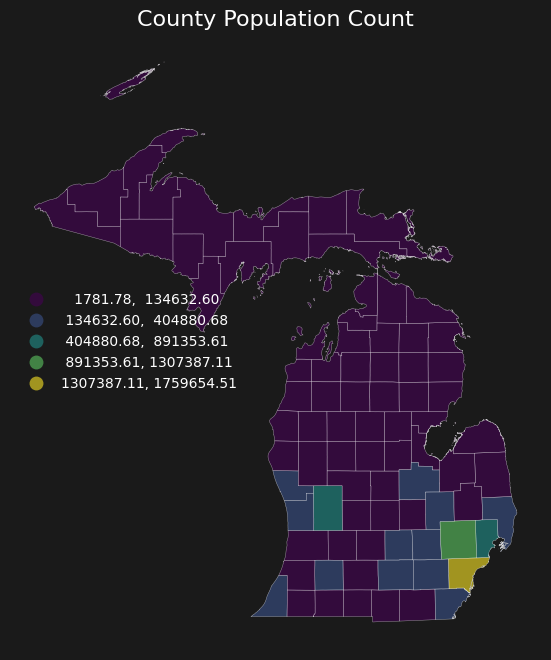

In [56]:
from src.main import plot_map_by_column
from src.main import ColorRamps 
from src.main import Schemes

plot_map_by_column(
    gdf_merged, 
    'sum', 
    ColorRamps.VIRIDIS, 
    Schemes.NATURAL_BREAKS, 
    'County Population Count')

## Nice Work! 
- We've extracted the total population counts per county with Earth Engine 
- Added the `sum` statistic to perform this reduction 
- We could now compare our derived population to census counts 
- You could use Population Count OR Density in your Risk Calculations 
- Make your case for which one provides a more accurate assessment!